# Sliding Window Decoding with a Tile Cache


This notebook demonstrates how to efficiently process a large tiled image
using a **sliding window** that caches already-decoded tiles.

It builds on the concepts introduced in `code_stream.ipynb`: ROI decoding and
tile-aligned batch decoding. Here we go one step further and show how to avoid
redundant decoding when the window moves across the image.


In [5]:
import os
import numpy as np
from matplotlib import pyplot as plt
resources_dir = os.getenv("PYNVIMGCODEC_EXAMPLES_RESOURCES_DIR", "../assets/images/")

from nvidia import nvimgcodec
decoder = nvimgcodec.Decoder()

def display(images, titles=None, figsize=(10, 4)):
    num_images = len(images)
    fig, axes = plt.subplots(1, num_images, figsize=figsize)
    if num_images == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.imshow(images[i])
        if titles is not None and i < len(titles):
            ax.set_title(titles[i])
        ax.axis('off')
    plt.tight_layout()
    plt.show()


In [6]:
img_full_path = os.path.abspath(os.path.join(resources_dir, "tiled-cat-1046544_640.jp2"))
cs = nvimgcodec.CodeStream(img_full_path)
print('Image size:', cs.height, 'x', cs.width)
print('Tile size: ', cs.tile_height, 'x', cs.tile_width)


Image size: 475 x 640
Tile size:  100 x 100


In many real-world applications — such as panoramic imagery, satellite scans,
or whole-slide medical images — you need to process a large image through a
sliding window. At each step the window overlaps significantly with the previous
position, so many of the underlying tiles remain the same.

Rather than re-decoding those tiles at every step, we maintain a **tile cache**:
a dictionary that maps `(tile_row, tile_col)` to its decoded pixel data.
For each new window position we:
1. Identify which tiles overlap the window.
2. Look up each tile in the cache — a **cache hit** costs nothing.
3. **Batch-decode** only the missing tiles in a single `decoder.decode()` call.
4. Assemble the window by stitching the (now fully cached) tiles together.


In [7]:
def tiles_for_window(y0, x0, win_h, win_w, tile_h, tile_w, nytiles, nxtiles):
    """Return the list of (tile_row, tile_col) tuples that overlap a given window."""
    tr0, tc0 = y0 // tile_h, x0 // tile_w
    tr1, tc1 = (y0 + win_h - 1) // tile_h, (x0 + win_w - 1) // tile_w
    return [
        (tr, tc)
        for tr in range(tr0, min(tr1 + 1, nytiles))
        for tc in range(tc0, min(tc1 + 1, nxtiles))
    ]


def assemble_window(relevant_tiles, tile_h, tile_w, y0, x0, win_h, win_w, img_h, img_w):
    """Stitch a subset of cached tiles into a single window array."""
    actual_h = min(win_h, img_h - y0)
    actual_w = min(win_w, img_w - x0)
    n_ch = next(iter(relevant_tiles.values())).shape[2]
    window = np.zeros((actual_h, actual_w, n_ch), dtype=np.uint8)
    for (tr, tc), tile in relevant_tiles.items():
        ty0, tx0 = tr * tile_h, tc * tile_w
        iy0 = max(y0, ty0);  iy1 = min(y0 + actual_h, ty0 + tile.shape[0])
        ix0 = max(x0, tx0);  ix1 = min(x0 + actual_w, tx0 + tile.shape[1])
        if iy1 <= iy0 or ix1 <= ix0:
            continue
        window[iy0-y0:iy1-y0, ix0-x0:ix1-x0] = tile[iy0-ty0:iy1-ty0, ix0-tx0:ix1-tx0]
    return window


We choose a window size of **250 × 300 pixels** and a step size equal to one
tile (100 × 100). This means that after a horizontal step exactly one new column
of tiles enters the window while two columns are already cached — giving an
immediate 2/3 hit rate that grows further as the scan continues.


In [8]:
win_h, win_w = 250, 300        # sliding window size in pixels
step_y = cs.tile_height        # step = one tile row
step_x = cs.tile_width         # step = one tile column

nytiles = (cs.height + cs.tile_height - 1) // cs.tile_height
nxtiles = (cs.width  + cs.tile_width  - 1) // cs.tile_width

tile_cache   = {}   # {(tile_row, tile_col): np.ndarray}
cache_hits   = 0
cache_misses = 0
windows          = []   # assembled window arrays
window_positions = []   # (y0, x0) for each window

for y0 in range(0, cs.height - win_h + 1, step_y):
    for x0 in range(0, cs.width - win_w + 1, step_x):

        needed  = tiles_for_window(y0, x0, win_h, win_w,
                                    cs.tile_height, cs.tile_width, nytiles, nxtiles)
        missing = [key for key in needed if key not in tile_cache]

        cache_hits   += len(needed) - len(missing)
        cache_misses += len(missing)

        # Batch-decode all missing tiles in a single decoder call
        if missing:
            srcs = []
            for (tr, tc) in missing:
                sy = tr * cs.tile_height;  ey = min(sy + cs.tile_height, cs.height)
                sx = tc * cs.tile_width;   ex = min(sx + cs.tile_width,  cs.width)
                srcs.append(cs.get_sub_code_stream(region=nvimgcodec.Region(sy, sx, ey, ex)))
            for key, img in zip(missing, decoder.decode(srcs)):
                tile_cache[key] = np.array(img.cpu())

        # Assemble window by stitching only the tiles it needs
        relevant = {k: tile_cache[k] for k in needed}
        windows.append(
            assemble_window(relevant, cs.tile_height, cs.tile_width,
                            y0, x0, win_h, win_w, cs.height, cs.width)
        )
        window_positions.append((y0, x0))

total = cache_hits + cache_misses
print(f"Windows scanned          : {len(windows)}")
print(f"Total tile accesses      : {total}")
print(f"  Cache hits             : {cache_hits}  ({100*cache_hits/total:.0f}%)")
print(f"  Tiles actually decoded : {cache_misses}  ({100*cache_misses/total:.0f}%)")
print(f"Unique tiles in cache    : {len(tile_cache)} out of {nytiles*nxtiles} total")


Windows scanned          : 12
Total tile accesses      : 108
  Cache hits             : 78  (72%)
  Tiles actually decoded : 30  (28%)
Unique tiles in cache    : 30 out of 35 total


Even with this small image the cache eliminates most redundant decodes.
Let's inspect a sample of the assembled windows:


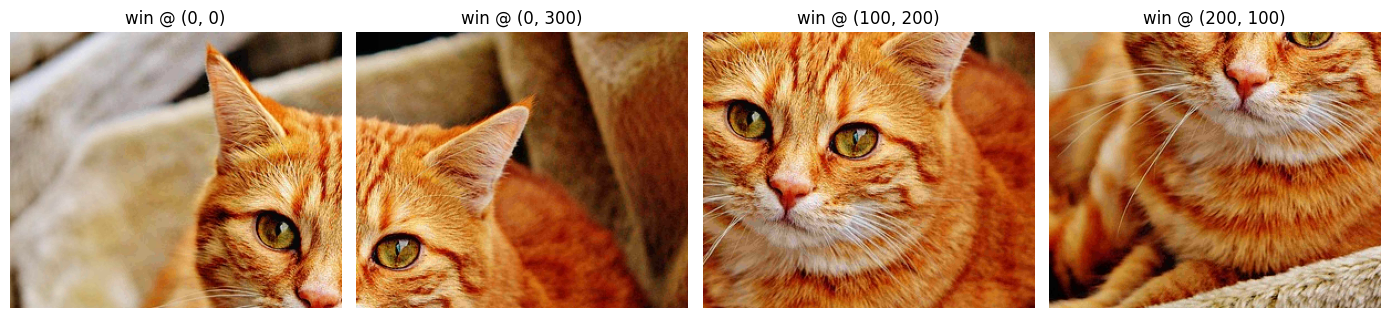

In [9]:
sample_indices = [0, len(windows) // 4, len(windows) // 2, 3 * len(windows) // 4]
display(
    [windows[i] for i in sample_indices],
    [f"win @ {window_positions[i]}" for i in sample_indices],
    figsize=(14, 4),
)


### Tile access heatmap

We can visualize how many windows overlapped each tile. Interior tiles are
covered by more windows than edge tiles, yet every tile was **decoded exactly
once** — the cache reuse is what makes the access count high.


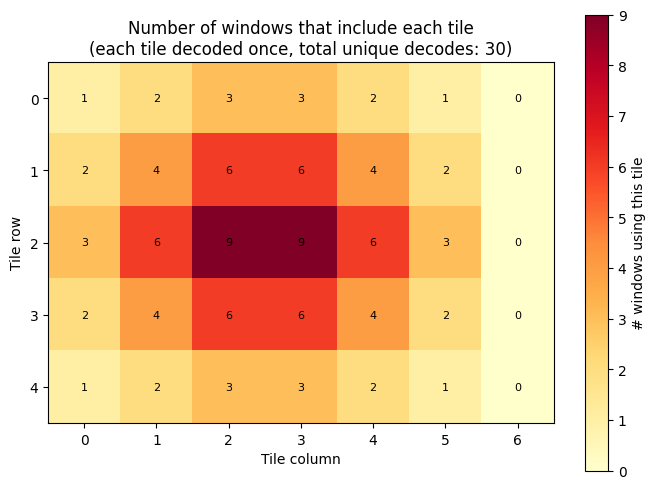

In [10]:
access_count = np.zeros((nytiles, nxtiles), dtype=int)
for y0, x0 in window_positions:
    for (tr, tc) in tiles_for_window(y0, x0, win_h, win_w,
                                      cs.tile_height, cs.tile_width, nytiles, nxtiles):
        access_count[tr, tc] += 1

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(access_count, cmap='YlOrRd')
for tr in range(nytiles):
    for tc in range(nxtiles):
        ax.text(tc, tr, str(access_count[tr, tc]),
                ha='center', va='center', fontsize=8)
ax.set_title('Number of windows that include each tile\n'
             f'(each tile decoded once, total unique decodes: {cache_misses})')
ax.set_xlabel('Tile column')
ax.set_ylabel('Tile row')
plt.colorbar(im, ax=ax, label='# windows using this tile')
plt.tight_layout()
plt.show()


## Bounded Cache: LRU Eviction Policy

For very large images the unbounded `dict` above eventually exhausts RAM.
The solution is a **Least-Recently-Used (LRU) cache**: keep at most *N* tiles
in memory; when the cache is full and a new tile is needed, discard the tile
that was accessed least recently.

Python's standard `collections.OrderedDict` provides O(1) move-to-end and
pop operations, making it the natural building block for an LRU cache with
no external dependencies.

In [ ]:
from collections import OrderedDict


class LRUTileCache:
    """Fixed-capacity tile cache with Least-Recently-Used eviction.

    Backed by :class:`collections.OrderedDict` so that promoting a hit
    and evicting the oldest entry are both O(1).
    """

    def __init__(self, maxsize):
        self.maxsize   = maxsize
        self._cache    = OrderedDict()
        self.hits      = 0
        self.misses    = 0
        self.evictions = 0

    def get(self, key):
        """Return ``(tile, True)`` on a hit (promoting to MRU), ``(None, False)`` on a miss."""
        if key in self._cache:
            self._cache.move_to_end(key)   # promote to most-recently used
            self.hits += 1
            return self._cache[key], True
        self.misses += 1
        return None, False

    def put(self, key, value):
        """Store a decoded tile, evicting the LRU entry if at capacity."""
        if key in self._cache:
            self._cache.move_to_end(key)
        else:
            if len(self._cache) >= self.maxsize:
                self._cache.popitem(last=False)   # evict least-recently used
                self.evictions += 1
        self._cache[key] = value

    def __len__(self):
        return len(self._cache)


def scan_with_lru(cs, decoder, cache, win_h, win_w, step_y, step_x):
    """Slide a window over *cs*, reusing tiles via *cache*.

    Drop-in replacement for the unbounded-dict loop: same batch-decode
    logic, same assembly step — only the cache type differs.
    """
    nytiles = (cs.height + cs.tile_height - 1) // cs.tile_height
    nxtiles = (cs.width  + cs.tile_width  - 1) // cs.tile_width
    windows = []

    for y0 in range(0, cs.height - win_h + 1, step_y):
        for x0 in range(0, cs.width - win_w + 1, step_x):
            needed    = tiles_for_window(y0, x0, win_h, win_w,
                                          cs.tile_height, cs.tile_width,
                                          nytiles, nxtiles)
            tile_data = {}
            missing   = []

            for key in needed:
                tile, hit = cache.get(key)
                if hit:
                    tile_data[key] = tile
                else:
                    missing.append(key)

            if missing:
                srcs = []
                for (tr, tc) in missing:
                    sy = tr * cs.tile_height;  ey = min(sy + cs.tile_height, cs.height)
                    sx = tc * cs.tile_width;   ex = min(sx + cs.tile_width,  cs.width)
                    srcs.append(cs.get_sub_code_stream(
                        region=nvimgcodec.Region(sy, sx, ey, ex)))
                for key, img in zip(missing, decoder.decode(srcs)):
                    arr = np.array(img.cpu())
                    cache.put(key, arr)
                    tile_data[key] = arr

            windows.append(
                assemble_window(tile_data, cs.tile_height, cs.tile_width,
                                y0, x0, win_h, win_w, cs.height, cs.width)
            )

    return windows

### Choosing the cache capacity

For a left-to-right, top-to-bottom scan the window overlaps at most

> **⌈win\_h / tile\_h⌉ + 1  tile rows simultaneously**

With a 250 px window and 100 px tiles that is **3 tile rows × 7 tile columns = 21 tiles**.
Setting `maxsize = 3 * nxtiles` guarantees that every tile required by the current window
is always present — the LRU hit rate matches the unbounded `dict` while capping
memory to three rows of pixel data.

A cache of only **`1 * nxtiles = 7` tiles** is too small: tiles from the top row
of the window compete for slots with tiles from the bottom row, triggering evictions
and **re-decoding** of tiles that were decoded just moments before.

In [ ]:
# Optimal LRU: 3 tile rows cover the full window height with no wasted decodes
optimal_size = 3 * nxtiles           # 21 tiles for this image
lru_optimal  = LRUTileCache(maxsize=optimal_size)
scan_with_lru(cs, decoder, lru_optimal, win_h, win_w, step_y, step_x)

total_opt = lru_optimal.hits + lru_optimal.misses
print(f"=== LRU (capacity = 3 × nxtiles = {optimal_size} tiles) ===")
print(f"  Hits       : {lru_optimal.hits}  ({100*lru_optimal.hits/total_opt:.0f}%)")
print(f"  Misses     : {lru_optimal.misses}  ({100*lru_optimal.misses/total_opt:.0f}%)")
print(f"  Evictions  : {lru_optimal.evictions}")
print(f"  Peak memory: ≤{optimal_size} tiles  (vs all {len(tile_cache)} tiles for unbounded dict)")
print()
print(f"Unbounded dict  — hits: {cache_hits}, misses: {cache_misses}, "
      f"peak memory: {len(tile_cache)} tiles")

In [ ]:
# Under-sized LRU: only 1 tile row — triggers evictions and re-decoding
tight_size = nxtiles          # 7 tiles for this image
lru_tight  = LRUTileCache(maxsize=tight_size)
scan_with_lru(cs, decoder, lru_tight, win_h, win_w, step_y, step_x)

total_tight   = lru_tight.hits + lru_tight.misses
extra_decodes = lru_tight.misses - cache_misses   # tiles re-decoded after eviction
print(f"=== LRU (capacity = 1 × nxtiles = {tight_size} tiles) ===")
print(f"  Hits          : {lru_tight.hits}  ({100*lru_tight.hits/total_tight:.0f}%)")
print(f"  Misses        : {lru_tight.misses}  ({100*lru_tight.misses/total_tight:.0f}%)")
print(f"  Evictions     : {lru_tight.evictions}")
print(f"  Extra decodes : +{extra_decodes}  (tiles re-decoded after eviction)")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels      = ['Unbounded\ndict',
               f'LRU  {optimal_size} tiles\n(3 × tile rows)',
               f'LRU  {tight_size} tiles\n(1 × tile row)']
hits_v      = [cache_hits,         lru_optimal.hits,      lru_tight.hits]
misses_v    = [cache_misses,       lru_optimal.misses,    lru_tight.misses]
evictions_v = [0,                  lru_optimal.evictions, lru_tight.evictions]

x     = np.arange(len(labels))
width = 0.28

# Left — absolute tile accesses
ax = axes[0]
bh = ax.bar(x - width, hits_v,      width, label='Cache hits', color='steelblue')
bm = ax.bar(x,         misses_v,    width, label='Decodes',    color='salmon')
be = ax.bar(x + width, evictions_v, width, label='Evictions',  color='gold')
ax.set_xticks(x);  ax.set_xticklabels(labels)
ax.set_ylabel('Count'); ax.set_title('Tile accesses per scan')
ax.legend(loc='upper left')
for group in (bh, bm, be):
    for bar in group:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, str(int(h)),
                    ha='center', va='bottom', fontsize=8)

# Right — hit rate
ax = axes[1]
totals = [h + m for h, m in zip(hits_v, misses_v)]
rates  = [100 * h / t for h, t in zip(hits_v, totals)]
bars   = ax.bar(x, rates, color=['steelblue', 'seagreen', 'salmon'])
ax.set_xticks(x);  ax.set_xticklabels(labels)
ax.set_ylabel('Cache hit rate (%)'); ax.set_title('Hit rate by policy')
ax.set_ylim(0, 105)
for bar, r in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width() / 2, r + 1, f'{r:.0f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()